# Librerías

In [ ]:
# Use this initial code to work in the notebook as if it were a module, that 
# is, to be able to export classes and functions from other subpackages.

import os
import sys

package_path = os.path.abspath('.').split(os.sep + 'notebooks')[0]
if package_path not in sys.path:
    sys.path.append(package_path)

%load_ext autoreload
%autoreload 2

In [ ]:
import os
from pathlib import Path

import dask.array as da
from dask.diagnostics import ProgressBar

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import numpy as np
import pandas as pd
import xarray as xr

from spectralcrop import PathManager

# Abrir Zarr e inspeccionar

In [ ]:
ds = xr.open_zarr(ZARR_PATH, chunks={"band": 64, "y": 512, "x": 512})

# Variables clave (band,y,x) -> transponer a (y,x,band) para trabajar cómodo
refl_byx = ds["reflectance"].transpose("y", "x", "band")
wavelengths = ds["wavelength"].values.astype(float)
fwhm = ds["fwhm"].values.astype(float)
ndvi = ds["NDVI"]
veg_mask = ds["veg_mask"].astype("bool")
written_bands = ds["written_bands"]

print(refl_byx)
print("wavelengths:", wavelengths.shape, "nm  |  fwhm:", fwhm.shape, "nm")
print("NDVI dims:", ndvi.dims, "veg_mask dims:", veg_mask.dims)

# Consistencias útiles para checklist
wl_min, wl_max = float(np.nanmin(wavelengths)), float(np.nanmax(wavelengths))
b_out = int(refl_byx.sizes["band"])
wb_all_ones = bool(int(to_numpy(written_bands).min()) == 1 and int(to_numpy(written_bands).max()) == 1)
print(f"Bandas exportadas: {b_out}, λ: {wl_min:.1f}–{wl_max:.1f} nm, written_bands all=1? {wb_all_ones}")

<xarray.DataArray 'reflectance' (y: 3660, x: 3438, band: 379)> Size: 19GB
dask.array<transpose, shape=(3660, 3438, 379), dtype=float32, chunksize=(512, 512, 64), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) int32 2kB 0 1 2 3 4 5 6 7 ... 372 373 374 375 376 377 378
Dimensions without coordinates: y, x
Attributes:
    dimension_names:    ['band', 'y', 'x']
    _ARRAY_DIMENSIONS:  ['band', 'y', 'x']
wavelengths: (379,) nm  |  fwhm: (379,) nm
NDVI dims: ('y', 'x') veg_mask dims: ('y', 'x')
Bandas exportadas: 379, λ: 411.0–2449.2 nm, written_bands all=1? True


C:\Users\JMONTOYA\AppData\Local\Temp\ipykernel_22960\144975827.py:1: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  ds = xr.open_zarr(ZARR_PATH, chunks={"band": 64, "y": 512, "x": 512})
C:\Users\JMONTOYA\AppData\Local\Temp\ipykernel_22960\144975827.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "band" starting at index 64. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(ZARR_PATH, chunks={"band": 64, "y": 512, "x": 512})


# Ajustar PCA

In [ ]:
# --- PCA (3 componentes) con modos 'all' y 'selected' ---
# Mantiene tu MIN_VALID_RATIO_PER_BAND basado en valid_ratio GLOBAL (no se recalcula aquí)

import os, json
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from sklearn.decomposition import IncrementalPCA

# ========= Parámetros =========
RNG = np.random.default_rng(42)
N_COMPONENTS = 3
SAMPLE_SIZE = 200_000            # número máximo de píxeles muestreados
BATCH_SIZE = 2000                # tamaño de lote IncrementalPCA
CHUNKS_YX = 512                  # chunk espacial para PCs
WATER_EXCLUSIONS = [(1340.0, 1440.0), (1800.0, 1950.0)]  # nm
MIN_VALID_RATIO_PER_BAND = 0.45  # <-- Mantienes este umbral global

# Rutas (ajusta si difieren en tu repo; se convierten a Path robustamente)
INTERIM_DIR       = Path(str(INTERIM_DATA))
REPORTS_DIR_PATH  = Path(str(REPORTS_DIR))
OUT_ZARR_DIR      = Path("../data/processed/zarr");   OUT_ZARR_DIR.mkdir(parents=True, exist_ok=True)
OUT_TIF_DIR       = Path("../data/processed/geotiff"); OUT_TIF_DIR.mkdir(parents=True, exist_ok=True)

EXPORT_GEOTIFF = False  # True si quieres GeoTIFF además de Zarr
crs = None              # p.ej., "EPSG:32618" si EXPORT_GEOTIFF=True
transform = None        # tu Affine transform si EXPORT_GEOTIFF=True

# ========= Utilidades =========
def bands_excluding_windows(wavelengths_nm: np.ndarray, windows_nm):
    """Índices de bandas cuyo λ NO cae en ninguna ventana de exclusión."""
    wl = np.asarray(wavelengths_nm, dtype=float)
    mask = np.ones_like(wl, dtype=bool)
    for a, b in windows_nm:
        mask &= ~((wl >= a) & (wl <= b))
    return np.where(mask)[0]

def intersect_sorted(a, b):
    """Intersección ordenada de arrays de índices."""
    return np.intersect1d(np.asarray(a, int), np.asarray(b, int), assume_unique=False)

def sample_veg_coords(veg_mask: xr.DataArray, mask_nodata: xr.DataArray, rng, kmax: int):
    """Devuelve (ys, xs, n_total_veg_valid) muestreados en vegetación válida (veg_mask ∧ mask_nodata==0)."""
    mask_valid = (veg_mask.data.astype(bool)) & (mask_nodata.data == 0)
    coords = np.column_stack(np.where(mask_valid))
    n = coords.shape[0]
    if n == 0:
        raise RuntimeError("No hay píxeles válidos en vegetación (verifica veg_mask y mask_nodata).")
    k = int(min(kmax, n))
    sel = rng.choice(n, size=k, replace=False)
    ys, xs = coords[sel, 0], coords[sel, 1]
    return ys.astype(int), xs.astype(int), n

def fit_pca_on_sample(refl_da: xr.DataArray, bands_idx: np.ndarray, ys, xs,
                      n_components=3, batch_size=2000):
    """
    Extrae matriz (N x B_used) sin NaNs por fila, centra por banda y ajusta IncrementalPCA.
    Devuelve (ipca, band_mean_all, used_rows).
    """
    # Extraer (N x B_used)
    spec = refl_da.isel(band=xr.DataArray(bands_idx, dims="band"),
                        y=xr.DataArray(ys, dims="points"),
                        x=xr.DataArray(xs, dims="points")).transpose("points","band")
    X = spec.astype("float32").values

    # Filtra filas completas sin NaN (crítico para IncrementalPCA)
    row_ok = np.all(np.isfinite(X), axis=1)
    X = X[row_ok]
    if X.shape[0] == 0:
        raise RuntimeError("Muestra para PCA quedó vacía tras filtrar NaNs. Baja MIN_VALID_RATIO_PER_BAND o revisa máscaras.")

    # Centro por banda (no escalo)
    band_mean_all = X.mean(axis=0, dtype="float64")
    Xc = X - band_mean_all

    ipca = IncrementalPCA(n_components=n_components, batch_size=batch_size)
    ipca.fit(Xc)

    return ipca, band_mean_all, int(X.shape[0])

def project_pcs(refl_da: xr.DataArray, bands_idx: np.ndarray, band_mean_all: np.ndarray, ipca, chunks_yx=512):
    """Proyecta PCs sobre toda la escena usando las mismas bandas y media por banda."""
    cube_sub = refl_da.isel(band=xr.DataArray(bands_idx, dims="band"))
    cube_c = cube_sub - xr.DataArray(band_mean_all, dims=["band"])
    comps = ipca.components_.astype("float32")  # (pc, band_used)

    pcs = []
    for i in range(comps.shape[0]):
        w = xr.DataArray(comps[i], dims=["band"])
        pcs.append((cube_c * w).sum(dim="band"))
    pcs_da = xr.concat(pcs, dim="pc").transpose("pc","y","x").astype("float32")
    pcs_da = pcs_da.assign_coords(pc=np.arange(1, comps.shape[0]+1)).rename("PCA")
    pcs_da = pcs_da.chunk({"pc": -1, "y": chunks_yx, "x": chunks_yx})
    return pcs_da

def export_pcs_geotiff(pcs_da: xr.DataArray, out_path: Path, crs, transform):
    import rasterio
    pcs_np = np.stack([pcs_da.isel(pc=i).values for i in range(pcs_da.sizes["pc"])], axis=0)
    profile = {
        "driver": "GTiff", "height": pcs_np.shape[1], "width": pcs_np.shape[2],
        "count": pcs_np.shape[0], "dtype": "float32",
        "crs": crs, "transform": transform,
        "tiled": True, "blockxsize": 256, "blockysize": 256,
        "compress": "deflate", "predictor": 2, "bigtiff": "IF_SAFER"
    }
    with rasterio.open(out_path, "w", **profile) as dst:
        for i in range(pcs_np.shape[0]):
            dst.write(pcs_np[i], i+1)

# ========= Runner =========
def run_pca(
    mode="selected",
    bands_selected_csv=INTERIM_DIR / "bands_selected_by_segment.csv",
    water_exclusions=WATER_EXCLUSIONS,
    min_valid_ratio_per_band=MIN_VALID_RATIO_PER_BAND,
    export_geotiff=EXPORT_GEOTIFF,
    out_prefix="pca_components",
    valid_ratio_array=None  # <-- pasa tu valid_ratio GLOBAL ya calculado (np.ndarray shape (B,))
):
    """
    mode:
      - 'all'      → usa todas las bandas salvo exclusiones por agua
      - 'selected' → usa bandas seleccionadas intersectadas con exclusiones por agua

    min_valid_ratio_per_band:
      - Se aplica sobre el 'valid_ratio' GLOBAL que pasas en 'valid_ratio_array';
        si None o <=0, no filtra bandas por cobertura.
    """
    # 1) Construir set de bandas
    bands_all = np.arange(refl_byx.sizes["band"])
    bands_no_water = bands_excluding_windows(wavelengths, water_exclusions)

    if mode == "selected":
        if not Path(bands_selected_csv).exists():
            raise ValueError("No se encontró CSV de bandas seleccionadas para mode='selected'.")
        sel = pd.read_csv(bands_selected_csv)
        if "band_index" not in sel.columns:
            raise ValueError("El CSV de seleccionadas debe tener columna 'band_index'.")
        bands_sel = np.asarray(sel["band_index"].values, dtype=int)
        bands_used = intersect_sorted(bands_sel, bands_no_water)
    elif mode == "all":
        bands_used = np.asarray(bands_no_water, dtype=int)
    else:
        raise ValueError("mode debe ser 'selected' o 'all'.")

    # 2) Filtro por cobertura GLOBAL si se solicita (no se recalcula valid_ratio)
    if (valid_ratio_array is not None) and (min_valid_ratio_per_band > 0.0):
        vr = np.asarray(valid_ratio_array, dtype=float)
        keep = [int(b) for b in bands_used if (np.isfinite(vr[b]) and vr[b] >= min_valid_ratio_per_band)]
        bands_used = np.array(keep, dtype=int)

    if bands_used.size == 0:
        raise RuntimeError("No quedan bandas para PCA tras aplicar exclusiones/filtros (revisa parámetros).")

    # 3) Muestreo de vegetación válida
    ys, xs, n_veg = sample_veg_coords(veg_mask, mask_nodata, RNG, SAMPLE_SIZE)
    print(f"[PCA:{mode}] Vegetación total={n_veg:,} | muestra={ys.size:,} | bandas={bands_used.size}")

    # 4) Fit PCA
    ipca, band_mean_all, n_rows_used = fit_pca_on_sample(
        refl_byx, bands_used, ys, xs,
        n_components=N_COMPONENTS, batch_size=BATCH_SIZE
    )
    expl_var = ipca.explained_variance_ratio_.tolist()
    print(f"[PCA:{mode}] Varianza explicada: { [round(v,4) for v in expl_var] } (suma={sum(expl_var):.4f})")

    # 5) Proyección perezosa y guardado
    pcs_da = project_pcs(refl_byx, bands_used, band_mean_all, ipca, chunks_yx=CHUNKS_YX)

    zarr_name = f"{out_prefix}_{mode}.zarr"
    out_zarr = OUT_ZARR_DIR / zarr_name
    pcs_da.to_dataset().to_zarr(out_zarr, mode="w")

    meta = {
        "mode": mode,
        "n_components": N_COMPONENTS,
        "bands_used_count": int(bands_used.size),
        "bands_used": bands_used.tolist(),
        "water_exclusions_nm": water_exclusions,
        "min_valid_ratio_per_band": float(min_valid_ratio_per_band),
        "sample_size_requested": int(SAMPLE_SIZE),
        "sample_rows_used": int(n_rows_used),
        "random_state": 42,
        "explained_variance_ratio": expl_var
    }
    with open(REPORTS_DIR_PATH / f"{out_prefix}_{mode}_summary.json", "w") as f:
        json.dump(meta, f, indent=2)
    pd.Series(expl_var, index=[f"PC{i+1}" for i in range(N_COMPONENTS)]).to_csv(REPORTS_DIR_PATH / f"{out_prefix}_{mode}_explained_variance.csv")

    # 6) (Opcional) GeoTIFF
    if export_geotiff:
        if (crs is None) or (transform is None):
            raise ValueError("Define 'crs' y 'transform' si quieres exportar GeoTIFF.")
        out_tif = OUT_TIF_DIR / f"{out_prefix}_{mode}.tif"
        export_pcs_geotiff(pcs_da, out_tif, crs, transform)
        print(f"[PCA:{mode}] GeoTIFF escrito en: {out_tif}")

    print(f"[PCA:{mode}] Zarr escrito en: {out_zarr}")
    return pcs_da



In [ ]:
# Cargar valid_ratio GLOBAL previamente calculado (si lo tienes en CSV)

valid_ratio_csv = INTERIM_DIR / "valid_ratio_per_band.csv"
valid_ratio_array = None
if valid_ratio_csv.exists():
    valid_ratio_array = pd.read_csv(valid_ratio_csv)["valid_ratio"].values


valid_ratio_array

array([0.48700247, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700255, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700

In [ ]:
# 1) PCA con TODAS las bandas (excepto exclusiones por agua)
pcs_all = run_pca(
    mode="all",
    min_valid_ratio_per_band=MIN_VALID_RATIO_PER_BAND,
    valid_ratio_array=valid_ratio_array,
    out_prefix="pca_components"
)

c:\Users\JMONTOYA\Documents\personal_projects\thesis\.venv\Lib\site-packages\dask\array\core.py:1738: FutureWarning: The `numpy.column_stack` function is not implemented by Dask array. You may want to use the da.map_blocks function or something similar to silence this warning. Your code may stop working in a future release.
  warnings.warn(


[PCA:all] Vegetación total=6,055,113 | muestra=200,000 | bandas=379
[PCA:all] Varianza explicada: [0.9187, 0.0706, 0.0053] (suma=0.9947)


c:\Users\JMONTOYA\Documents\personal_projects\thesis\.venv\Lib\site-packages\zarr\api\asynchronous.py:244: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


[PCA:all] Zarr escrito en: ..\data\processed\zarr\pca_components_all.zarr


In [ ]:
# 2) PCA SOLO con bandas seleccionadas (intersectadas con exclusiones), mismo umbral global
pcs_sel = run_pca(
    mode="selected",
    min_valid_ratio_per_band=MIN_VALID_RATIO_PER_BAND,
    valid_ratio_array=valid_ratio_array,
    out_prefix="pca_components"
)

c:\Users\JMONTOYA\Documents\personal_projects\thesis\.venv\Lib\site-packages\dask\array\core.py:1738: FutureWarning: The `numpy.column_stack` function is not implemented by Dask array. You may want to use the da.map_blocks function or something similar to silence this warning. Your code may stop working in a future release.
  warnings.warn(


[PCA:selected] Vegetación total=6,055,113 | muestra=200,000 | bandas=58
[PCA:selected] Varianza explicada: [0.9077, 0.0795, 0.0063] (suma=0.9936)


c:\Users\JMONTOYA\Documents\personal_projects\thesis\.venv\Lib\site-packages\zarr\api\asynchronous.py:244: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


[PCA:selected] Zarr escrito en: ..\data\processed\zarr\pca_components_selected.zarr


In [ ]:
RNG = np.random.default_rng(42)

def sample_veg_coords(veg_mask_da: xr.DataArray, mask_nodata_da: xr.DataArray, rng, kmax: int):
    vm = np.asarray(veg_mask_da.data, dtype=bool)
    mn = np.asarray(mask_nodata_da.data == 0, dtype=bool)
    mask_valid = vm & mn

    idx = np.flatnonzero(mask_valid.ravel())
    if idx.size == 0:
        raise RuntimeError("No hay píxeles válidos en vegetación.")
    k = int(min(kmax, idx.size))
    sel = rng.choice(idx.size, size=k, replace=False)
    ys, xs = np.divmod(idx[sel], mask_valid.shape[1])
    return ys.astype(int), xs.astype(int), int(idx.size)

ys, xs, n_veg = sample_veg_coords(veg_mask, mask_nodata, RNG, kmax=50_000)
print(f"Vegetación válida total={n_veg:,} | muestra={ys.size:,}")

Vegetación válida total=6,055,113 | muestra=50,000


In [ ]:
# Extraer scores de la misma muestra espacial
Xa = pcs_all.isel(
    y=xr.DataArray(ys, dims="points"),
    x=xr.DataArray(xs, dims="points")
).transpose("points", "pc").values  # (N,3)

Xs = pcs_sel.isel(
    y=xr.DataArray(ys, dims="points"),
    x=xr.DataArray(xs, dims="points")
).transpose("points", "pc").values  # (N,3)

# Estandarizar columnas (evita escalas distintas por EVR)
Xa_z = (Xa - Xa.mean(0)) / (Xa.std(0) + 1e-9)
Xs_z = (Xs - Xs.mean(0)) / (Xs.std(0) + 1e-9)

# Correlaciones canónicas vía SVD de la matriz de correlación cruzada
C = (Xa_z.T @ Xs_z) / (Xa_z.shape[0] - 1)  # (3x3)
s = np.linalg.svd(C, compute_uv=False)     # singular values = can. corrs
print("Correlaciones canónicas (max 3):", np.round(s, 4))


Correlaciones canónicas (max 3): [1.0077 0.9935 0.9725]


In [ ]:
# === Helpers de selección de bandas ===
def if not mask.any():def nearest_band(target_nm, wavelengths_nm):
        # sin intersección: devolvemos la más cercana al centro del rango
        center = (wl_min + wl_max) / 2.0
        return nearest_band(center, wl)
    band_candidates = np.where(mask)[0]
    # elegimos la banda más cercana al centro del rango
    center = (wl_min + wl_max) / 2.0
    idx_local = int(np.argmin(np.abs(wl[mask] - center)))
    j = int(band_candidates[idx_local])
    return j, float(wl[j])

# === Selección de bandas canónicas aproximadas ===
band_green, wl_green = nearest_in_range(540, 560, wavelengths)
band_re,    wl_re    = nearest_in_range(705, 740, wavelengths)
band_nir,   wl_nir   = nearest_in_range(780, 840, wavelengths)
band_531,   wl_531   = nearest_in_range(525, 535, wavelengths)
band_570,   wl_570   = nearest_in_range(565, 575, wavelengths)
band_680,   wl_680   = nearest_in_range(675, 685, wavelengths)
band_500,   wl_500   = nearest_in_range(495, 505, wavelengths)
band_750,   wl_750   = nearest_in_range(745, 755, wavelengths)
band_red,   wl_red   = nearest_in_range(660, 680, wavelengths)

print(f"Green≈{wl_green:.1f}nm  RE≈{wl_re:.1f}nm  NIR≈{wl_nir:.1f}nm  "
      f"531≈{wl_531:.1f} 570≈{wl_570:.1f}  680≈{wl_680:.1f}  "
      f"500≈{wl_500:.1f}  750≈{wl_750:.1f}  Red≈{wl_red:.1f}")

# === Cálculo de índices con xarray (perezoso) ===
R = refl_byx  # reflectance (band, y, x)

def safe_div(a, b):  # evita división por cero
    return a / xr.where(np.abs(b) < 1e-6, np.nan, b)

# NDVI
R_nir = R.isel(band=band_nir)
R_red = R.isel(band=band_red)
NDVI = safe_div(R_nir - R_red, R_nir + R_red)

# NDRE
R_re = R.isel(band=band_re)
NDRE = safe_div(R_nir - R_re, R_nir + R_re)

# CIgreen = (NIR / Green) - 1
R_green = R.isel(band=band_green)
CIgreen = safe_div(R_nir, R_green) - 1.0

# PRI = (R531 - R570) / (R531 + R570)
R_531 = R.isel(band=band_531)
R_570 = R.isel(band=band_570)
PRI = safe_div(R_531 - R_570, R_531 + R_570)

# PSRI = (R680 - R500) / R750
R_680 = R.isel(band=band_680)
R_500 = R.isel(band=band_500)
R_750 = R.isel(band=band_750)
PSRI = safe_div(R_680 - R_500, R_750)

# === Extracción en la misma muestra espacial (ys, xs) ===
def sample_da(da, ys, xs):
    return da.isel(y=xr.DataArray(ys, dims="points"),
                   x=xr.DataArray(xs, dims="points")).values

# PCs (del modo selected)
pc2 = sample_da(pcs_sel.sel(pc=2), ys, xs)
pc3 = sample_da(pcs_sel.sel(pc=3), ys, xs)

# Índices
ndvi = sample_da(NDVI, ys, xs)
ndre = sample_da(NDRE, ys, xs)
cig  = sample_da(CIgreen, ys, xs)
pri  = sample_da(PRI, ys, xs)
psri = sample_da(PSRI, ys, xs)

def valid_mask(*arrs):
    m = np.ones_like(arrs[0], dtype=bool)
    for a in arrs:
        m &= np.isfinite(a)
    return m
    i = int(np.argmin(np.abs(wavelengths_nm - float(target_nm))))
    return i, float(wavelengths_nm[i])

def nearest_in_range(wl_min, wl_max, wavelengths_nm):
    wl = wavelengths_nm
    mask = (wl >= wl_min) & (wl <= wl_max)


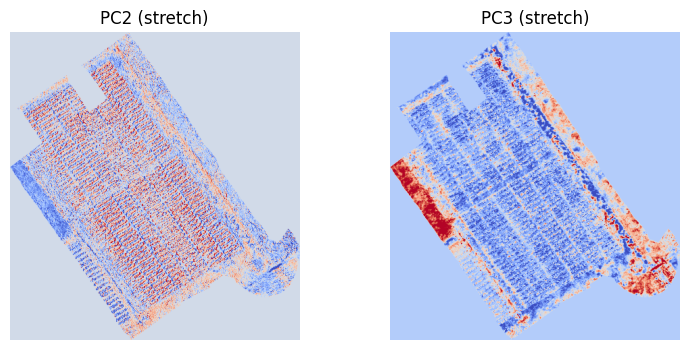

In [ ]:
def stretch(img, p=(2,98)):
    lo, hi = np.nanpercentile(img, p)
    return np.clip((img - lo) / (hi - lo + 1e-6), 0, 1)

pcs_low = pcs_sel.coarsen(y=8, x=8, boundary="trim").mean().compute()
pc2_img = stretch(pcs_low.sel(pc=2).values)
pc3_img = stretch(pcs_low.sel(pc=3).values)

fig, ax = plt.subplots(1,2, figsize=(9,4))
ax[0].imshow(pc2_img, cmap="coolwarm"); ax[0].set_title("PC2 (stretch)")
ax[1].imshow(pc3_img, cmap="coolwarm"); ax[1].set_title("PC3 (stretch)")
for a in ax: a.axis("off")
plt.show()